In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import gymnasium as gym
from tqdm import tqdm
import sys
sys.path.insert(0, "../src/")
from Network import *
from inputFuc import *
from plotting import *
from utilsRL import *
from IPython.display import display, clear_output
import time
import imageio
import pickle

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)

general_config['save_path'] = "../saved_models/Cartpole/"

#### With P learning ###
dt = general_config["dt"]
action_step = 0.02

# init both teacher and student net
batch = train_config["batch_size"]
general_config["device"] = "cpu"
device = general_config["device"]
print(device)

# Create the CartPole environment
env = CartPoleCustomize(obs='velocity')

n_actions = env.env.action_space.n.item()
# Get the number of state observations
obs, info = env.reset()
n_observations = obs.shape[-1]

actor_config = dict(default_model_config)
critic_config = dict(default_model_config)
actor_config['n_in'] = n_observations
critic_config['n_in'] = n_observations
actor_config['n_out'] = n_actions
critic_config['n_out'] = 1

cpu


# Train from scratch

In [3]:
def episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()
    device = actor.device

    terminated, truncated = False, False
    total_reward=0
    lamd = 0.9
    gamma = 0.99 # are they different?
    rwd_scale = 0.2

    interpolate = 3
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)
    observations = observations.to(device)
    delta_rec = 0

    with torch.no_grad():
        t = 0
        while not terminated and not truncated:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            if truncated:
                break
            reward *= rwd_scale

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]
            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value
            delta_rec += torch.abs(delta)           
            delta = torch.clamp(delta, -0.015, 0.015).to(device)
            actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions).to(device)-p)
            actor.backwardsRL(delta.item(), lamd)            
            critic.prop(1.)
            critic.backwardsRL(delta.item(), lamd)

            if t%150==0:
                torch.nn.utils.clip_grad_norm_(actor.parameters(), 0.8)
                torch.nn.utils.clip_grad_norm_(critic.parameters(), 0.8)
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)

            observation = observation_next
            total_reward+=reward
            t += 1

        torch.nn.utils.clip_grad_norm_(actor.parameters(), 0.8)
        torch.nn.utils.clip_grad_norm_(critic.parameters(), 0.8)
        optimizer_actor.step()
        optimizer_critic.step()
        optimizer_actor.zero_grad(set_to_none=False)
        optimizer_critic.zero_grad(set_to_none=False)
        soft_update(critic_target, critic, tau = 0.05)      

    return total_reward/rwd_scale, t, delta_rec/t

In [4]:
#Change schedular, add temporatue?
actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)
for p in critic_target.parameters():
    p.requires_grad = False
hard_update(critic_target, critic)
num_episode = 4000

optimizer_actor = torch.optim.Adam(
    actor.parameters(),
    lr=1e-4, 
    betas=(0.9, 0.999)
)

optimizer_critic = torch.optim.Adam(
    critic.parameters(),
    lr=1e-3, 
    betas=(0.9, 0.999)
)

In [5]:
save_dict = {'step':[], 'reward':[]}
R_avg, duration_avg, delta_avg = 10, 0, 0
best_R, best_duration = 0, 0
R_rec, delta_rec = [], []
for i in range(num_episode):
    total_reward, duration, delta = episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic)
    save_dict['step'].append(duration)
    save_dict['reward'].append(total_reward)
    if total_reward < R_avg:
        actor.beta *= 0.997
        critic.beta *= 0.997
    else:
        actor.beta += 0.001
        critic.beta += 0.001
    R_avg = 0.98*R_avg + 0.02*total_reward
    duration_avg = 0.98*duration_avg + 0.02*duration
    delta_avg = 0.98*delta_avg + 0.02*delta
    if i%100==99:
        R_rec.append(R_avg)
        saved = False
        if R_avg > best_R:
            best_R = R_avg
        print(f"Reward:{R_avg:.2f}, Steps:{duration_avg:.2f}, delta:{delta_avg.item():.3f}, beta:{actor.beta:.3f}")
    if duration_avg > 496 and R_avg > 490:
        best_R = R_avg
        print("Learning Success")
        break
best_actor_state = actor.state_dict().copy()
best_critic_state = critic.state_dict().copy()      
env.close() # Close the environment
save_dict['step'] = np.array(save_dict['step'])
save_dict['reward'] = np.array(save_dict['reward'])

Reward:18.32, Steps:16.99, delta:0.061, beta:0.953
Reward:20.24, Steps:20.07, delta:0.037, beta:0.839
Reward:41.06, Steps:41.04, delta:0.053, beta:0.807
Reward:51.46, Steps:51.45, delta:0.030, beta:0.737
Reward:53.37, Steps:53.36, delta:0.018, beta:0.667
Reward:59.39, Steps:59.39, delta:0.015, beta:0.610
Reward:62.58, Steps:62.58, delta:0.019, beta:0.543
Reward:53.15, Steps:53.14, delta:0.017, beta:0.471
Reward:50.17, Steps:50.17, delta:0.021, beta:0.430
Reward:57.18, Steps:57.18, delta:0.025, beta:0.408
Reward:72.63, Steps:72.63, delta:0.053, beta:0.406
Reward:85.04, Steps:85.04, delta:0.060, beta:0.402
Reward:107.18, Steps:107.18, delta:0.086, beta:0.413
Reward:108.57, Steps:108.57, delta:0.095, beta:0.386
Reward:149.12, Steps:149.12, delta:0.085, beta:0.388
Reward:128.40, Steps:128.40, delta:0.072, beta:0.352
Reward:124.18, Steps:124.18, delta:0.058, beta:0.331
Reward:128.50, Steps:128.50, delta:0.057, beta:0.330
Reward:179.39, Steps:179.39, delta:0.045, beta:0.363
Reward:243.85, St

### Saving

In [17]:
torch.save(best_actor_state, general_config['save_path']+"actor%d.ckp"%int(best_R))
torch.save(best_critic_state, general_config['save_path']+"critic%d.ckp"%int(best_R))

In [18]:
save_path = "../Figures/CartpoleTrainRecord.pkl"
with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)

All_record.append(save_dict)

with open(save_path, 'wb') as handle:
    pickle.dump(All_record, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Make figure

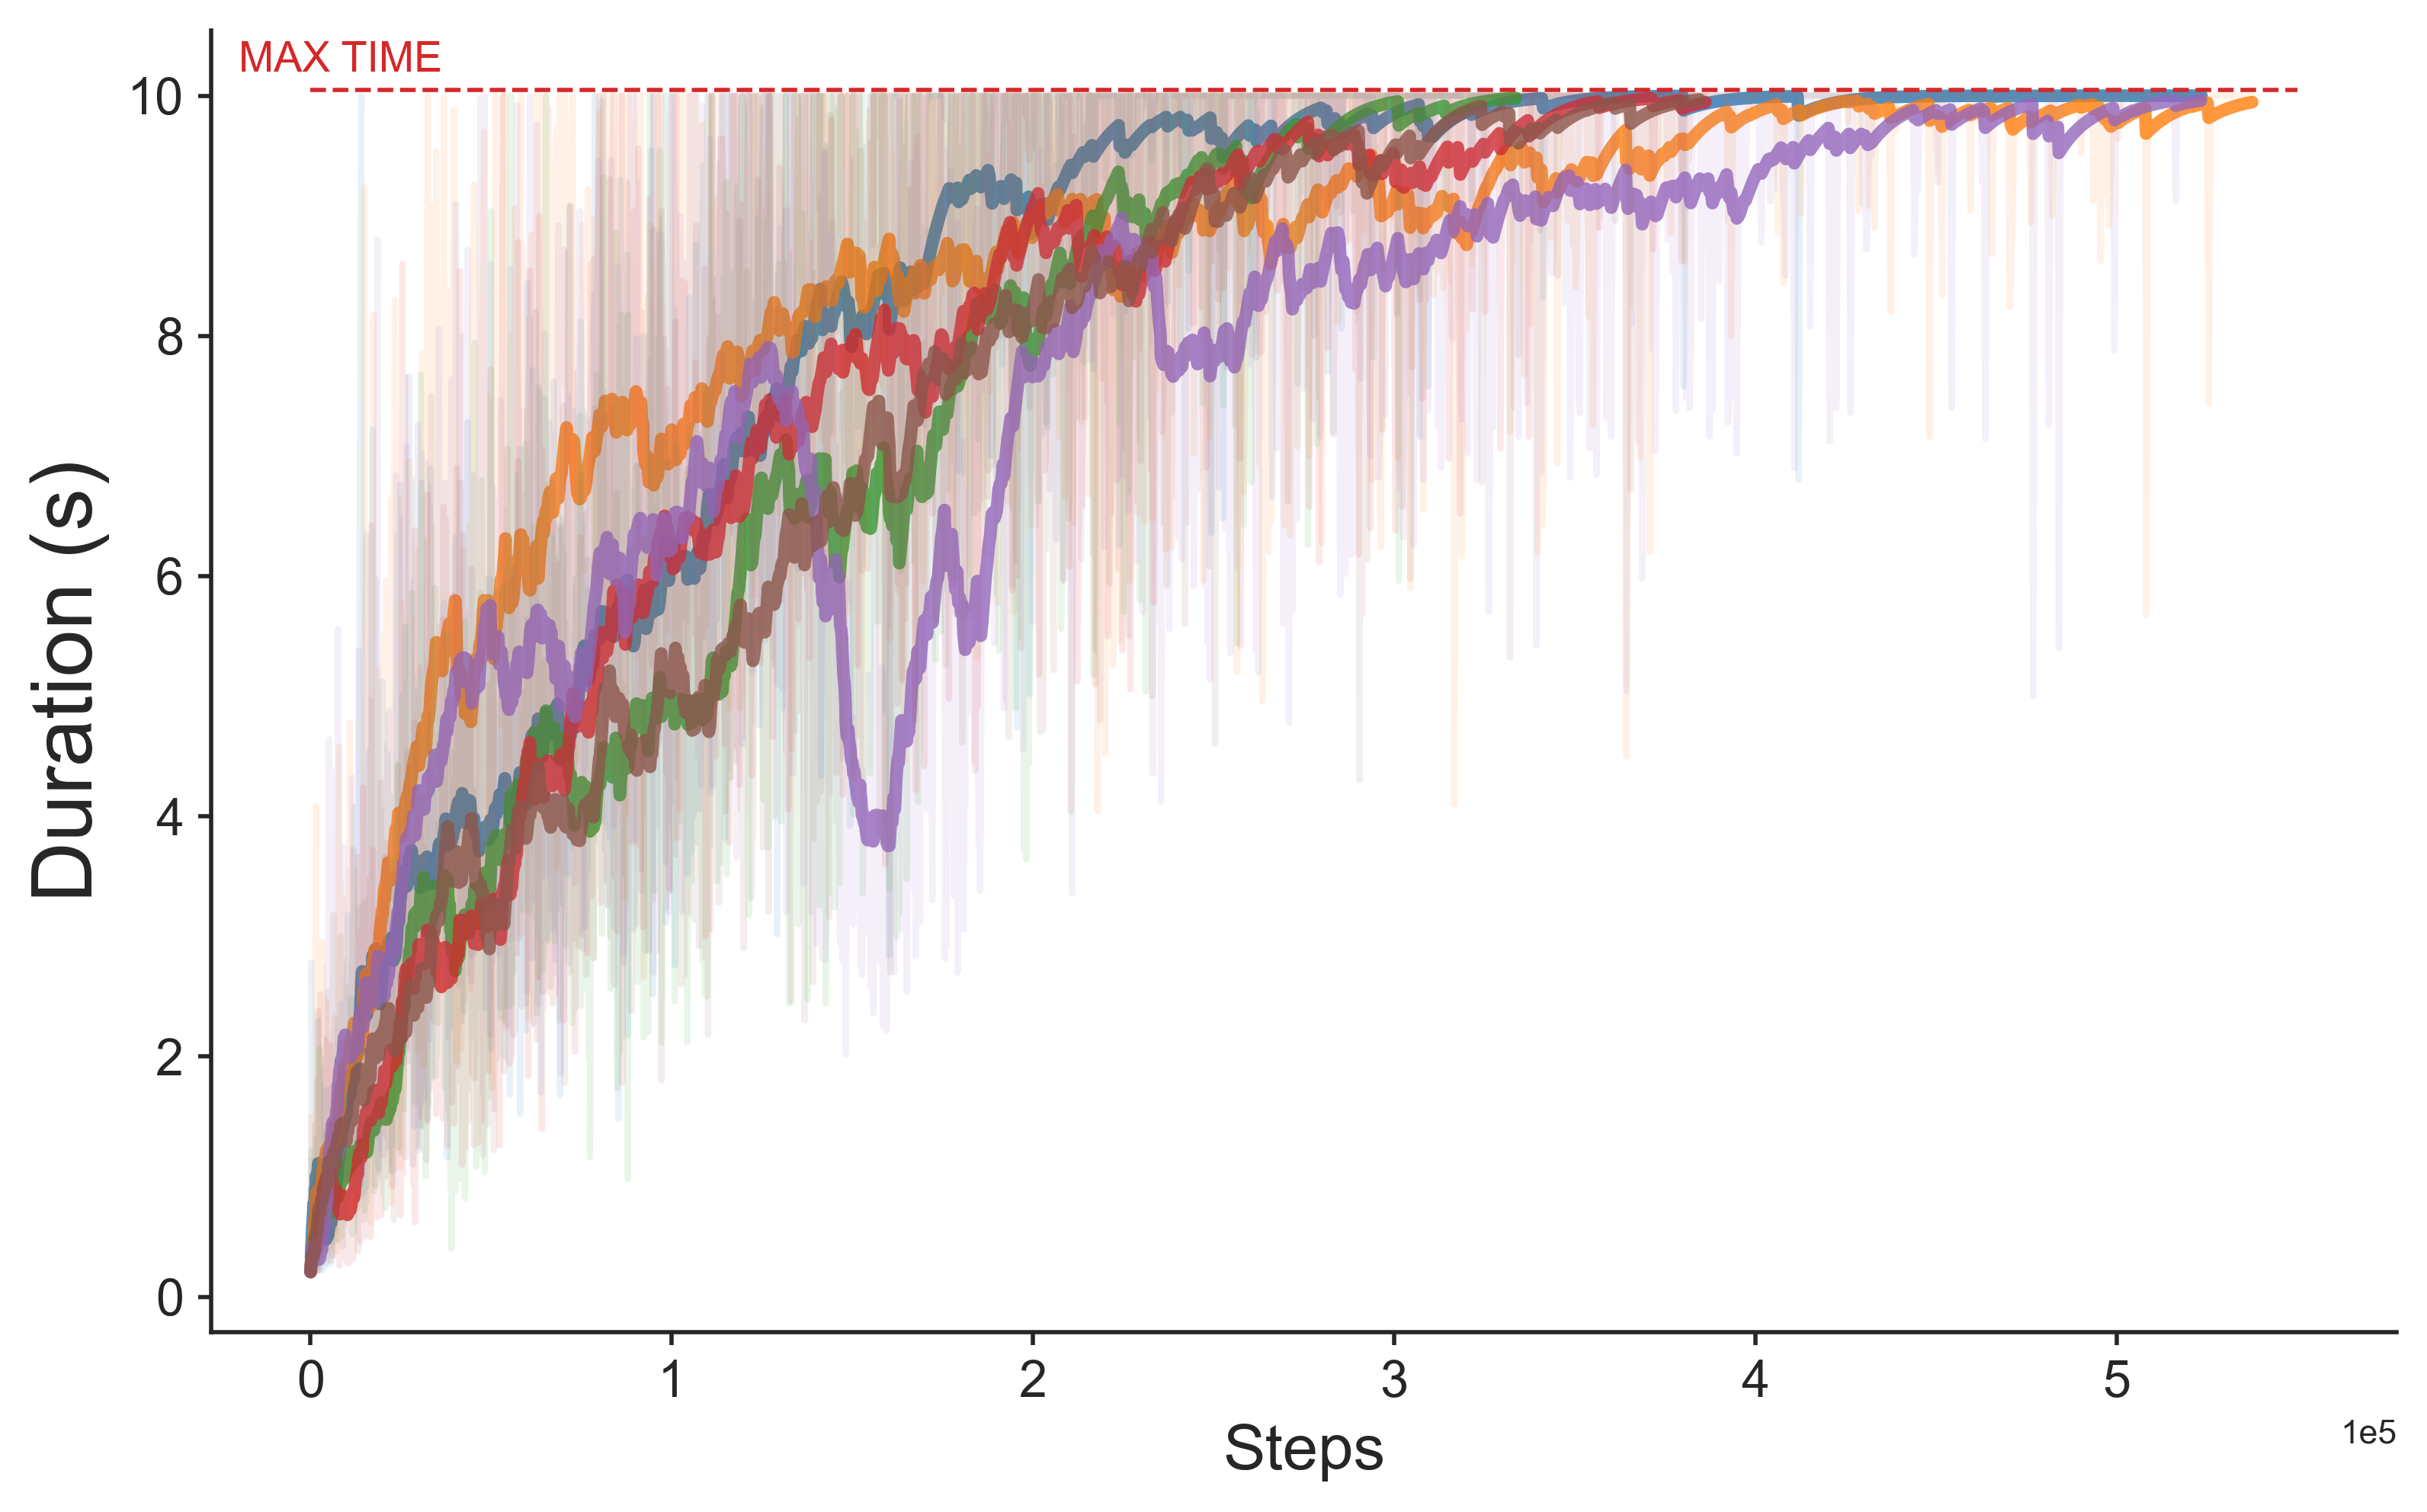

In [61]:
save_path = "../Figures/CartpoleTrainRecord.pkl"
with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)
color=[
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    '#bcbd22', '#17becf'
]

fig, ax = plt.subplots(figsize = (8, 5), dpi=400)
for j, one_train in enumerate(All_record[:6]):
    #plt.plot()
    step = one_train['step']
    cum_step = np.cumsum(step)
    smoothed = []
    t_lp = 10#step[0]
    for i, t in enumerate(step):
        t_lp = 0.95*t_lp + 0.05*t
        smoothed.append(t_lp)
    smoothed = np.array(smoothed)*action_step
    ax.plot(cum_step, step*action_step, alpha = 0.1, color=color[j])
    ax.plot(cum_step, smoothed, color=color[j], linewidth=3., alpha=0.8)
ax.set_xlabel("Steps", fontsize=15)
#ax.set_xticks([1e4, 2e4], [])
ax.set_ylabel("Duration (s)", fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
ax.tick_params(axis='both', which='major', labelsize=12)
ax.hlines(y=10.05, xmin=0, xmax=5.5e5, linestyle='--', linewidth=1, color=red)
ax.annotate("MAX TIME", xy=(-2e4, 10.2), color=red, fontsize=10)

plt.tight_layout()
plt.savefig('../Figures/CartpoleDuration.png')
plt.show()

In [40]:
All_record

[{'step': array([139, 110,  57, ..., 500, 500, 500], shape=(1550,)),
  'reward': array([116.80238 , 100.26077 ,  52.871445, ..., 453.2529  , 496.9324  ,
         499.99808 ], shape=(1550,), dtype=float32)},
 {'step': array([ 36,  21,  15, ..., 500, 500, 500], shape=(1450,)),
  'reward': array([ 31.212093,  17.242592,  10.178204, ..., 474.69394 , 499.93185 ,
         497.03336 ], shape=(1450,), dtype=float32)},
 {'step': array([ 26,  45,  12, ..., 500, 500, 500], shape=(1412,)),
  'reward': array([ 15.615462,  33.0902  ,   8.760232, ..., 499.99808 , 499.99808 ,
         475.52634 ], shape=(1412,), dtype=float32)},
 {'step': array([ 15,  18,  26, ..., 500, 500, 500], shape=(1504,)),
  'reward': array([ 10.829059,  13.138813,  22.496593, ..., 499.59076 , 469.8216  ,
         499.99808 ], shape=(1504,), dtype=float32)},
 {'step': array([ 18,  15,  16, ..., 500, 500, 500], shape=(1684,)),
  'reward': array([ 12.954169,  10.83519 ,  11.35595 , ..., 488.2369  , 499.95026 ,
         499.99808 

# Adaptation and visulize (IN PROGRESS)

In [3]:
Durations = {}
Rewards = {}

In [4]:
def episode_interpolate_adapt(env, actor, critic, critic_target, 
                              optimizer_actor, optimizer_critic,
                              adapt=False, visualize=False,):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    lamd, gamma = 0.9, 0.99
    rwd_scale = 0.2
    baseline = 0

    interpolate = 3
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 20 #ms
    if visualize:
        plt.figure(figsize=(5,4))
    frames = []

    with torch.no_grad():
        t = 0
        while not terminated and t<1000:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                if adapt:
                    value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            total_reward += reward
            reward *= rwd_scale
            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]
            
            frame = env.render()
            frames.append(frame)
            if visualize:
                plt.imshow(frame)
                plt.axis("off")
                display(plt.gcf())
                clear_output(wait=True)
            
            if adapt:
                for k in range(1, interpolate):
                    value_next,_ = critic_target.step(observations[k])
    
                delta = reward + gamma*value_next - value
                delta = torch.clamp(delta, -0.02, 0.02)

                # baseline = 0.9 * baseline + 0.1 * delta
                # delta = delta - baseline
                #print(action, delta.item(), baseline)

                actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
                critic.prop(1.)
                actor.backwardsRL(delta.item(), lamd)
                critic.backwardsRL(delta.item(), lamd)

            observation = observation_next
            t+=1
            if adapt and t%150==0:
                #print(actor.layers[-2].W_in.grad.data.norm(2))
                torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
                torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)
                #soft_update(critic_target, critic, tau = 0.05) 

    return total_reward, t, frames

In [24]:
num_trials = 200
wind = -6.

visualize = False
env = WindCartPoleEnv(wind=wind, render_mode="rgb_array")
env = CartPoleCustomize(env=env)  #Do we need time limit?
#env = CartPoleCustomize(env=None, display = True)
actor_state_dict = torch.load(general_config['save_path']+"actor493.ckp", weights_only=False)
critic_state_dict = torch.load(general_config['save_path']+"critic493.ckp", weights_only=False)

actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)

In [45]:
#Without online adpation
noAdapt_reward, noAdapt_time = [], []
actor.load_state_dict(actor_state_dict)
critic.load_state_dict(critic_state_dict)
critic_target.load_state_dict(critic_state_dict)

for i in range(num_trials):
    total_reward, t, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     None, None, adapt=False, visualize=visualize,)
    noAdapt_reward.append(total_reward)
    noAdapt_time.append(t)
    if total_reward < 0:
        imageio.mimsave("../Figures/cartpole_noAdapt%.1f.gif"%total_reward, frames, fps=30)

noAdapt_reward = np.array(noAdapt_reward)
noAdapt_time = np.array(noAdapt_time)
print("Average Reward without adaptation: ", noAdapt_reward.mean())

Average Reward without adaptation:  190.11043


In [20]:
#With online adpation
Adapt_reward, Adapt_time = [], []
for i in range(num_trials):
    actor.load_state_dict(actor_state_dict)
    critic.load_state_dict(critic_state_dict)
    critic_target.load_state_dict(critic_state_dict)
    # optimizer_actor = torch.optim.RMSprop(
    #     actor.parameters(),
    #     lr=1e-4, alpha=0.6
    # )
    # optimizer_critic = torch.optim.RMSprop(
    #     critic.parameters(),
    #     lr=1e-3, alpha=0.6
    # )

    optimizer_actor = torch.optim.SGD(
        actor.parameters(),
        lr=2e-4,
    )
    optimizer_critic = torch.optim.SGD(
        critic.parameters(),
        lr=0e-4,
    )
    
    total_reward, t, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     optimizer_actor, optimizer_critic,
                                                     adapt=True, visualize=visualize,)
    Adapt_reward.append(total_reward)
    Adapt_time.append(t)
    #if total_reward > 750:
        #imageio.mimsave("../Figures/cartpole_Adapt%.1f.gif"%total_reward, frames, fps=30)
Adapt_reward = np.array(Adapt_reward)
Adapt_time = np.array(Adapt_time)
print("Average Reward with adaptation: ", Adapt_reward.mean())

Average Reward with adaptation:  456.8719


0.675 0.805


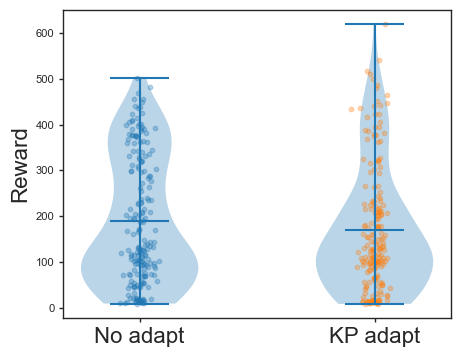

In [47]:
#TODO plot the bar with many runs
fig, ax = plt.subplots(figsize = (5, 4))

data = [noAdapt_reward, Adapt_reward]
#data = [noAdapt_time, Adapt_time]
ax.violinplot(data, positions=[0,1], showmeans=True)
ax.set_xticks([0,1], ['No adapt', 'KP adapt'], fontsize=16)
ax.set_ylabel("Reward", fontsize=16)

for i, d in enumerate(data):
    x = np.random.normal(i, 0.03, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.3, s=10)

failure = 300
print((noAdapt_time < failure).sum()/num_trials, (Adapt_time < failure).sum()/num_trials)
Durations[wind] = [noAdapt_time, Adapt_time]
Rewards[wind] = [noAdapt_reward, Adapt_reward]
#plt.savefig('../Figures/CartpoleAdpation.png')
plt.show()

NameError: name 'Rewards' is not defined

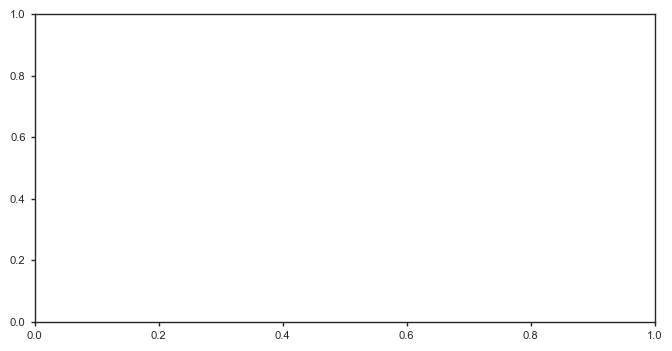

In [6]:
fig, ax = plt.subplots(figsize = (8, 4))
forces = np.array([5.2, 5.6, 6., 6.4])
colors = [blue, orange]

noAdapt, Adapt = [], []
for force in forces:
    noAd, Ad = Rewards[-force]
    noAdapt.append(noAd)
    Adapt.append(Ad)

for j, data in enumerate([noAdapt, Adapt]):
    pos = forces-0.08+j*0.16
    ax.violinplot(data, positions=pos, showmeans=True, widths=0.2)
    color = colors[j]
    for i, d in enumerate(data):
        x = np.random.normal(pos[i], 0.02, size=len(d))  # small horizontal jitter
        ax.scatter(x, d, alpha=0.6, s=10, color=color)

ax.set_xticks(forces)
ax.set_ylabel("Reward", fontsize=16)
ax.set_xlabel('Wind Strength', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=15)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors[0], label='No Adapt'),
    plt.Rectangle((0, 0), 1, 1, color=colors[1], label='Adapt'),
]
# Legend inside plot box
#ax.set_ylim(94, 99)
ax.legend(handles=handles, loc='best', frameon=False, fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('../Figures/CartpoleAdpation.png')
plt.tight_layout()
plt.show()

In [42]:
Durations

{6.0: [array([1000,  339,  540, 1000,  537,  558, 1000,  928,  512, 1000,  329,
          586,  935,  478,  578, 1000, 1000,  247,  314,  737,  588, 1000,
          592,  628,  699,  898,  642,  608, 1000, 1000,  544, 1000,  362,
         1000,  531,  376, 1000, 1000,  292,  236,  954,  816,  766,  106,
          462,  782, 1000,  425, 1000,  774,  357,  626,  387, 1000, 1000,
          376, 1000,  414,  754,  255,  304,  323,  914,  593,  683,  600,
          452,  391, 1000,  492, 1000, 1000,  722,  119,  843,  950, 1000,
          355,  793, 1000, 1000,  464, 1000,  321,  671,  726,  759,  812,
          298,  523,  588,  210,  751,  231,  284,  815, 1000,  562, 1000,
          750]),
  array([ 148,  391,  533,  914,  314,  424,  747,  484,  586, 1000,  611,
          647,  926,  127,  672,  494, 1000,  518,  125, 1000,  826,  227,
          476, 1000,  352,  938,  558,  461,  710,  294, 1000, 1000, 1000,
         1000,  375,  807, 1000, 1000,  844, 1000, 1000,  239,  258,  921,
   

In [14]:
class SimpleCartPoleController:
    def __init__(self):
        self.k_x = 0.5
        self.k_x_dot = 0.1
        self.k_theta = 5.0
        self.k_theta_dot = 0.5

        self.bias = 0.0
        self.alpha = 0.01

    def act(self, obs):
        x, x_dot, theta, theta_dot = obs

        self.bias += self.alpha * x

        u = -(self.k_x * x +
              self.k_x_dot * x_dot +
              self.k_theta * theta +
              self.k_theta_dot * theta_dot +
              self.bias)

        return 1 if u > 0 else 0, abs(u)  # return confidence

def episode_adapt_controller(env, actor, controller, optimizer_actor, adapt=False):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()

    terminated, truncated = False, False
    total_reward=0

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 20 #ms
    frames = []
    obs_avg = 0

    with torch.no_grad():
        t = 0
        while not terminated and t<1000:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            if adapt:
                # --- controller signal ---
                observation_full = env.obs
                ctrl_action, ctrl_conf = controller.act(observation_full)
                # confidence scaling (optional but important)
                conf = min(1.0, ctrl_conf / 10.0)
                # supervised direction
                target = F.one_hot(torch.tensor(ctrl_action), num_classes=n_actions).float()
                # policy gradient-style update toward controller
                signal = (target - p) * conf
                
                actor.prop(signal)
                actor.backwards()
                if t % 80 == 0:
                    torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.)
                    optimizer_actor.step()
                    optimizer_actor.zero_grad(set_to_none=False)

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            total_reward += reward
            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]
            obs_avg = env.obs**2 + obs_avg
            
            frame = env.render()
            frames.append(frame)

            observation = observation_next
            t += 1

    return total_reward, t, frames, obs_avg/t

In [15]:
#https://statusfailed.com/blog/2022-12-08-pid-controller-in-the-openai-gym/
class PD:
    def __init__(self, kp, kd, goal):
        self.kp = kp
        self.kd = kd
        self.goal = goal
        self.last_error = 0

    def observe(self, x):
        error = self.goal - x
        d_error = error - self.last_error
        self.last_error = error
        return self.kp * error + self.kd * d_error

class PD2Controller:
    def __init__(self):
        #self.cart = PD(kp=2, kd=100, goal=0)
        self.cart = PD(kp=2, kd=100, goal=0)
        self.pole = PD(kp=5, kd=100, goal=0)

    def act(self, obs):
        cart_position, _, pole_angle, _ = obs
        u_cart = self.cart.observe(cart_position)
        u_pole = self.pole.observe(pole_angle)
        action = 1 if u_pole + u_cart < 0 else 0
        return action, 1

class TwoLoopPIDController:
    def __init__(self):
        # outer loop (position → angle)
        self.kp_x = 5. #0.5
        self.kd_x = 0.2
        self.ki_x = 0.02

        # inner loop (angle → force)
        self.kp_theta = 8.0
        self.kd_theta = 0.8

        self.x_int = 0.0

    def act(self, obs):
        x, x_dot, theta, theta_dot = obs

        # integral (compensates wind)
        self.x_int += x

        # outer loop: desired angle
        theta_target = (
            self.kp_x * x +
            self.kd_x * x_dot +
            self.ki_x * self.x_int
        )

        # inner loop: track angle
        u = self.kp_theta * (theta - theta_target) + self.kd_theta * theta_dot

        action = 1 if u > 0 else 0

        confidence = abs(u)
        return action, confidence

In [27]:
Adapt_reward, Adapt_time, Adapt_obs = [], [], []
for i in range(num_trials):
    actor.load_state_dict(actor_state_dict)
    optimizer_actor = torch.optim.RMSprop(
        actor.parameters(),
        lr=1e-4, alpha=0.8
    )
    # optimizer_actor = torch.optim.SGD(
    #     actor.parameters(),
    #     lr=1e-4,
    # )
    controller = PD2Controller()
    #controller = TwoLoopPIDController()
    total_reward, t, frames, obs_avg = episode_adapt_controller(env, actor, controller, optimizer_actor, adapt=True)
    Adapt_reward.append(total_reward)
    Adapt_obs.append(obs_avg)
    Adapt_time.append(t)
    #if total_reward > 750:
        #imageio.mimsave("../Figures/cartpole_Adapt%.1f.gif"%total_reward, frames, fps=30)
Adapt_reward = np.array(Adapt_reward)
Adapt_time = np.array(Adapt_time)
Adapt_obs = np.array(Adapt_obs)
print("Average Reward with adaptation: ", Adapt_reward.mean())

Average Reward with adaptation:  386.265


In [26]:
Adapt_obs.mean(axis=0)

array([1.090211  , 0.48621193, 0.01332242, 0.27329293], dtype=float32)

In [28]:
Adapt_obs.mean(axis=0)

array([1.0287133 , 0.56022394, 0.01272424, 0.26416332], dtype=float32)

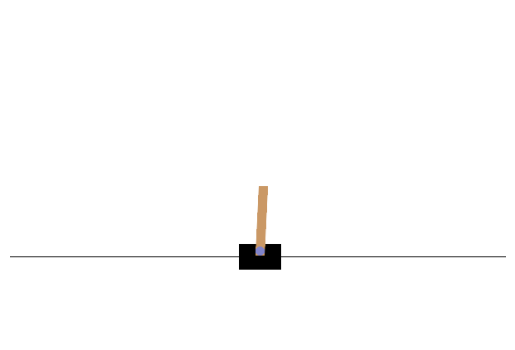

In [38]:
fig, ax = plt.subplots()
ax.imshow(frames[25])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_yticks([])
ax.set_xticks([])
plt.savefig('../Figures/cartpoleAnim.png')
plt.show()

In [52]:
#TODO multi-episode learn, faster than BPTT?